# 1. Install dependencies (run once)

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install numpy scipy matplotlib pandas seaborn tqdm
!pip install torch_geometric

import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import hashlib

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.1 MB/s eta 0:00:00
Using device: cuda


# 2. Bayesian Layers


In [2]:
class BayesianRLayerNorm(nn.Module):
    def __init__(self, normalized_shape, prior_scale=1.0):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.gamma_mu = nn.Parameter(torch.ones(normalized_shape))
        self.gamma_logvar = nn.Parameter(torch.zeros(normalized_shape))
        self.beta_mu = nn.Parameter(torch.zeros(normalized_shape))
        self.beta_logvar = nn.Parameter(torch.zeros(normalized_shape))
        self.prior_scale = prior_scale

    def forward(self, x):
        if self.training:
            gamma = self.gamma_mu + torch.exp(0.5 * self.gamma_logvar) * torch.randn_like(self.gamma_mu)
            beta = self.beta_mu + torch.exp(0.5 * self.beta_logvar) * torch.randn_like(self.beta_mu)
        else:
            gamma = self.gamma_mu
            beta = self.beta_mu
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True) + 1e-5
        return gamma * (x - mean) / std + beta

class BayesianPASA:
    def __init__(self, initial_rank=10, uncertainty_threshold=0.1, max_rank=50):
        self.rank = initial_rank
        self.threshold = uncertainty_threshold
        self.max_rank = max_rank

    def update_rank(self, eigenvalues, eigenvalue_uncertainties):
        high_uncertainty = eigenvalue_uncertainties > self.threshold
        if high_uncertainty.any():
            self.rank = min(self.rank + 5, self.max_rank)
        return self.rank

# 3. EPANG‑Gen with Memory‑Efficient Eigenspace


In [3]:
class EPANGGen(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 rank=10, oversampling=5, eigen_update_freq=100,
                 use_curvature_lr=True, negative_curvature_threshold=1e-4,
                 smoothing=0.9, pasa=None):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)
        self.rank = rank
        self.oversampling = oversampling
        self.eigen_update_freq = eigen_update_freq
        self.use_curvature_lr = use_curvature_lr
        self.negative_curvature_threshold = negative_curvature_threshold
        self.smoothing = smoothing
        self.pasa = pasa
        self._step_count = 0
        self._preconditioner = None
        self._eigenvalues = None
        self._eigenvectors = None
        self.power_iters = 1

    def _randomized_eigenspace(self, grad_flat):
        """Memory-efficient eigen-decomposition using diagonal approximation."""
        d = grad_flat.shape[0]

        # Adaptive rank based on problem size
        effective_rank = min(self.rank, d // 100) if d > 10000 else self.rank
        k = min(effective_rank + self.oversampling, d)

        # Use diagonal Hessian approximation to save memory
        with torch.no_grad():
            # Generate random matrix
            Omega = torch.randn(d, k, device=grad_flat.device, dtype=grad_flat.dtype)

            # Power iterations with diagonal approximation
            Y = Omega
            for _ in range(self.power_iters):
                # Approximate Hessian diagonal using gradient variance
                if hasattr(self, '_grad_sq'):
                    self._grad_sq.mul_(0.9).add_(grad_flat**2 * 0.1)
                else:
                    self._grad_sq = grad_flat**2
                H_diag = self._grad_sq + 1e-8
                Y = H_diag.unsqueeze(1) * Y

            # QR decomposition
            Q, _ = torch.linalg.qr(Y)

            # Form T = Q^T H Q (using same diagonal)
            T = Q.t() @ (H_diag.unsqueeze(1) * Q)

            # Small eigendecomposition
            eigvals, eigvecs_T = torch.linalg.eigh(T)
            idx = torch.argsort(eigvals, descending=True)
            eigvals = eigvals[idx][:effective_rank]
            eigvecs_T = eigvecs_T[:, idx][:, :effective_rank]

            # Approximate eigenvectors of H
            V = Q @ eigvecs_T

        return V, eigvals

    def _update_preconditioner(self, grad_flat):
        V, eigvals = self._randomized_eigenspace(grad_flat)
        scaling = torch.diag(1.0 / torch.sqrt(eigvals + self.defaults['eps']))
        new_precond = V @ scaling @ V.T
        if self._preconditioner is None:
            self._preconditioner = new_precond
        else:
            self._preconditioner = (self.smoothing * self._preconditioner +
                                    (1 - self.smoothing) * new_precond)
        self._eigenvalues = eigvals
        self._eigenvectors = V
        if self.pasa is not None:
            uncertainties = torch.ones_like(eigvals) * 0.05
            self.rank = self.pasa.update_rank(eigvals.cpu().numpy(), uncertainties.cpu().numpy())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()

        self._step_count += 1
        for group in self.param_groups:
            beta1, beta2 = group['betas']
            lr = group['lr']

            grad_list = []
            shape_list = []
            for p in group['params']:
                if p.grad is None:
                    continue
                grad_list.append(p.grad.view(-1))
                shape_list.append(p.grad.shape)
            if not grad_list:
                continue
            grad_flat = torch.cat(grad_list)

            if self._step_count % self.eigen_update_freq == 1:
                # Clear cache before eigen update
                torch.cuda.empty_cache()
                self._update_preconditioner(grad_flat)
                torch.cuda.empty_cache()

            if self._preconditioner is not None:
                scaled_g_flat = self._preconditioner @ grad_flat
            else:
                scaled_g_flat = grad_flat

            idx = 0
            for p, shp in zip(group['params'], shape_list):
                if p.grad is None:
                    continue
                numel = p.numel()
                scaled_g = scaled_g_flat[idx:idx+numel].view(shp)
                idx += numel

                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['momentum'] = torch.zeros_like(p)
                    state['second_moment'] = torch.zeros_like(p)

                state['step'] += 1
                state['second_moment'].mul_(beta2).addcmul_(p.grad, p.grad, value=1-beta2)
                state['momentum'].mul_(beta1).add_(scaled_g, alpha=1-beta1)

                if self.use_curvature_lr and self._eigenvalues is not None:
                    median_eig = self._eigenvalues.median().item()
                    lr_adapted = lr / (np.sqrt(median_eig + group['eps']))
                else:
                    lr_adapted = lr

                p.add_(state['momentum'], alpha=-lr_adapted)

        return loss

# 4. Manual ADOPT


In [4]:
class ManualADOPT(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, clip_value=1.0):
        defaults = dict(lr=lr, betas=betas, eps=eps, clip_value=clip_value)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()

        for group in self.param_groups:
            beta1, beta2 = group['betas']
            lr = group['lr']
            eps = group['eps']
            clip_value = group['clip_value']

            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad
                torch.nn.utils.clip_grad_norm_([p], clip_value)

                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)
                    state['exp_avg_sq'] = torch.zeros_like(p)
                    state['prev_grad'] = torch.zeros_like(p)

                state['step'] += 1
                step = state['step']
                exp_avg = state['exp_avg']
                exp_avg_sq = state['exp_avg_sq']
                prev_grad = state['prev_grad']

                if step > 1:
                    exp_avg_sq.mul_(beta2).addcmul_(prev_grad, prev_grad, value=1-beta2)
                    denom = exp_avg_sq.sqrt().add_(eps)
                    normalized_grad = grad / denom
                else:
                    normalized_grad = grad

                exp_avg.mul_(beta1).add_(normalized_grad, alpha=1-beta1)
                p.add_(exp_avg, alpha=-lr)
                prev_grad.copy_(grad)

        return loss

# 5. Neural Network


In [5]:
class BayesianPINN(nn.Module):
    def __init__(self, layers, prior_scale=1.0):
        super().__init__()
        self.linears = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:
                self.norms.append(BayesianRLayerNorm(layers[i+1], prior_scale))
    def forward(self, x):
        for i, (linear, norm) in enumerate(zip(self.linears[:-1], self.norms)):
            x = linear(x)
            x = norm(x)
            x = torch.tanh(x)
        x = self.linears[-1](x)
        return x

# 6. Problem Definitions (4 benchmarks)


In [6]:

def poisson_1d_loss(model, x_colloc, x_bc, u_bc):
    x_colloc.requires_grad_(True)
    u = model(x_colloc)
    u_x = torch.autograd.grad(u, x_colloc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_colloc, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    f = torch.pi**2 * torch.sin(torch.pi * x_colloc)
    loss_pde = torch.mean((u_xx + f)**2)
    u_bc_pred = model(x_bc)
    loss_bc = torch.mean((u_bc_pred - u_bc)**2)
    return loss_pde + loss_bc

def burgers_loss(model, x_colloc, t_colloc, x_data, t_data, u_data):
    x_colloc.requires_grad_(True)
    t_colloc.requires_grad_(True)
    xt = torch.cat([x_colloc, t_colloc], dim=1)
    u = model(xt)
    u_t = torch.autograd.grad(u, t_colloc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_colloc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_colloc, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    nu = 0.01
    f = u_t + u * u_x - nu * u_xx
    loss_pde = torch.mean(f**2)
    u_data_pred = model(torch.cat([x_data, t_data], dim=1))
    loss_data = torch.mean((u_data_pred - u_data)**2)
    return loss_pde + loss_data

def darcy_2d_loss(model, x_colloc, y_colloc, x_bc, y_bc, u_bc):
    x_colloc.requires_grad_(True)
    y_colloc.requires_grad_(True)
    xy = torch.cat([x_colloc, y_colloc], dim=1)
    u = model(xy)
    u_x = torch.autograd.grad(u, x_colloc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y_colloc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    k_val = 1.0
    flux_x = k_val * u_x
    flux_y = k_val * u_y
    div_flux = torch.autograd.grad(flux_x, x_colloc, grad_outputs=torch.ones_like(flux_x), create_graph=True)[0] + \
               torch.autograd.grad(flux_y, y_colloc, grad_outputs=torch.ones_like(flux_y), create_graph=True)[0]
    source = 1.0
    loss_pde = torch.mean((div_flux + source)**2)
    xy_bc = torch.cat([x_bc, y_bc], dim=1)
    u_bc_pred = model(xy_bc)
    loss_bc = torch.mean((u_bc_pred - u_bc)**2)
    return loss_pde + loss_bc

def helmholtz_2d_loss(model, x_colloc, y_colloc, x_bc, y_bc, u_bc):
    k = 10.0
    x_colloc.requires_grad_(True)
    y_colloc.requires_grad_(True)
    xy = torch.cat([x_colloc, y_colloc], dim=1)
    u = model(xy)
    u_x = torch.autograd.grad(u, x_colloc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y_colloc, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_colloc, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_colloc, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    q = torch.sin(k * x_colloc) * torch.sin(k * y_colloc)
    residual = u_xx + u_yy + k**2 * u - q
    loss_pde = torch.mean(residual**2)
    xy_bc = torch.cat([x_bc, y_bc], dim=1)
    u_bc_pred = model(xy_bc)
    loss_bc = torch.mean((u_bc_pred - u_bc)**2)
    return loss_pde + loss_bc

# 7. Training Function

In [7]:
def train_problem(problem_name, optimizer_name, seed, epochs=5000):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Model configuration
    if problem_name == 'poisson_1d':
        layers = [1, 50, 50, 1]
        data_fn = generate_poisson_1d
        loss_fn = poisson_1d_loss
    elif problem_name == 'burgers':
        layers = [2, 100, 100, 100, 1]
        data_fn = generate_burgers
        loss_fn = burgers_loss
    elif problem_name == 'darcy_2d':
        layers = [2, 100, 100, 100, 1]
        data_fn = generate_darcy_2d
        loss_fn = darcy_2d_loss
    elif problem_name == 'helmholtz_2d':
        layers = [2, 100, 100, 100, 1]
        data_fn = generate_helmholtz_2d
        loss_fn = helmholtz_2d_loss

    model = BayesianPINN(layers).to(device)
    model.train()
    data_args = data_fn()
    data_args = [arg.to(device) if torch.is_tensor(arg) else arg for arg in data_args]

    # Optimizer selection
    if optimizer_name == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    elif optimizer_name == 'ADOPT':
        opt = ManualADOPT(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8)
    elif optimizer_name == 'EPANG-Gen':
        pasa = BayesianPASA(initial_rank=10)
        opt = EPANGGen(model.parameters(), lr=1e-3, rank=10, eigen_update_freq=100, pasa=pasa)
    elif optimizer_name == 'AdamW':
        opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    elif optimizer_name == 'EPANG-Gen-light':
        opt = EPANGGen(model.parameters(), lr=1e-3, rank=10,
                       eigen_update_freq=10000, use_curvature_lr=False)
    elif optimizer_name == 'L-BFGS':
        opt = torch.optim.LBFGS(model.parameters(), lr=1e-3, history_size=10)

    loss_history = []
    time_start = time.time()
    for epoch in tqdm(range(epochs), desc=f"{problem_name}-{optimizer_name}-seed{seed}"):
        def closure():
            opt.zero_grad()
            loss = loss_fn(model, *data_args)
            loss.backward()
            return loss.item()
        loss = opt.step(closure)
        loss_history.append(loss)
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: loss = {loss:.6f}")

    time_total = time.time() - time_start
    return {
        'problem': problem_name,
        'optimizer': optimizer_name,
        'seed': seed,
        'loss_history': loss_history,
        'final_loss': loss_history[-1],
        'time': time_total
    }

In [8]:
# =============================================================================
# Add these data generator functions before train_problem()
# =============================================================================

def generate_poisson_1d(n_colloc=1000, n_bc=2):
    x_colloc = torch.rand(n_colloc, 1) * 2 - 1
    x_bc = torch.tensor([[-1.0], [1.0]])
    u_bc = torch.tensor([[0.0], [0.0]])
    return x_colloc, x_bc, u_bc

def generate_burgers(n_colloc=2000, n_data=100):
    x_colloc = torch.rand(n_colloc, 1) * 2 - 1
    t_colloc = torch.rand(n_colloc, 1) * 1.0
    x_data = torch.rand(n_data, 1) * 2 - 1
    t_data = torch.rand(n_data, 1) * 1.0
    u_data = torch.sin(torch.pi * x_data) * torch.exp(-0.01 * t_data)
    return x_colloc, t_colloc, x_data, t_data, u_data

def generate_darcy_2d(n_colloc=5000, n_bc=400):
    x_colloc = torch.rand(n_colloc, 1) * 2 - 1
    y_colloc = torch.rand(n_colloc, 1) * 2 - 1
    theta = torch.rand(n_bc, 1) * 2 * np.pi
    x_bc = torch.cos(theta)
    y_bc = torch.sin(theta)
    u_bc = torch.zeros(n_bc, 1)
    return x_colloc, y_colloc, x_bc, y_bc, u_bc

def generate_helmholtz_2d(n_colloc=5000, n_bc=400):
    x_colloc = torch.rand(n_colloc, 1) * 2 - 1
    y_colloc = torch.rand(n_colloc, 1) * 2 - 1
    x_bc = torch.cat([torch.rand(n_bc//2,1)*2-1, torch.ones(n_bc//4,1), -torch.ones(n_bc//4,1)])
    y_bc = torch.cat([torch.ones(n_bc//2,1), torch.rand(n_bc//4,1)*2-1, torch.rand(n_bc//4,1)*2-1])
    u_bc = torch.zeros(n_bc, 1)
    return x_colloc, y_colloc, x_bc, y_bc, u_bc

# 8. Main Experiment

In [9]:
optimizers_to_run = ['Adam', 'ADOPT', 'EPANG-Gen', 'AdamW', 'EPANG-Gen-light', 'L-BFGS']
problems_to_run = ['poisson_1d', 'burgers', 'darcy_2d', 'helmholtz_2d']
seeds = [42, 43, 44]
epochs_per_run = 5000

results = []
total_runs = len(optimizers_to_run) * len(problems_to_run) * len(seeds)
print(f"Total runs in this notebook: {total_runs}")

run_counter = 0
for opt_name in optimizers_to_run:
    for prob_name in problems_to_run:
        for seed in seeds:
            run_counter += 1
            print(f"\n=== Run {run_counter}/{total_runs}: {opt_name} on {prob_name}, seed {seed} ===")
            result = train_problem(prob_name, opt_name, seed, epochs=epochs_per_run)
            results.append(result)
            with open(f"results_{opt_name}_{prob_name}_seed{seed}.json", 'w') as f:
                json.dump(result, f, indent=2)

Total runs in this notebook: 72

=== Run 1/72: Adam on poisson_1d, seed 42 ===


poisson_1d-Adam-seed42:   0%|          | 0/5000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
poisson_1d-Adam-seed42:   0%|          | 8/5000 [00:00<07:29, 11.10it/s]  

Epoch 0: loss = 48.000656


poisson_1d-Adam-seed42:  10%|█         | 508/5000 [00:09<01:13, 61.19it/s]

Epoch 500: loss = 38.752159


...

helmholtz_2d-L-BFGS-seed44:  80%|████████  | 4003/5000 [03:52<00:48, 20.71it/s]

Epoch 4000: loss = 982.744690


helmholtz_2d-L-BFGS-seed44:  90%|█████████ | 4504/5000 [04:19<00:24, 20.61it/s]

Epoch 4500: loss = 850.321289


helmholtz_2d-L-BFGS-seed44: 100%|██████████| 5000/5000 [04:45<00:00, 17.49it/s]



=== EXPERIMENT COMPLETE ===
Summary: {'Adam_poisson_1d': {'mean': 10.711721738179525, 'std': 1.6885832664658624, 'raw': [11.5477294921875, 8.35650634765625, 12.230929374694824]}, 'Adam_burgers': {'mean': 0.15266875177621841, 'std': 0.03842527464099877, 'raw': [0.20287901163101196, 0.14556223154067993, 0.10956501215696335]}, 'Adam_darcy_2d': {'mean': 0.2843788266181946, 'std': 0.0861800514092717, 'raw': [0.3943401575088501, 0.2749160826206207, 0.18388023972511292]}, 'Adam_helmholtz_2d': {'mean': 20.140718539555866, 'std': 18.214836140241285, 'raw': [45.48029327392578, 3.4584696292877197, 11.483392715454102]}, 'ADOPT_poisson_1d': {'median': 8.794229984283447, 'iqr': 3.949272632598877, 'raw': [12.743502616882324, 4.84495735168457], 'nan_count': 1}, 'ADOPT_burgers': {'median': 0.3164752796292305, 'iqr': 0.14353158324956894, 'raw': [0.46000686287879944, 0.17294369637966156], 'nan_count': 1}, 'ADOPT_darcy_2d': {'median': 0.8180349469184875, 'iqr': 0.11366641521453857, 'raw': [0.931701362133

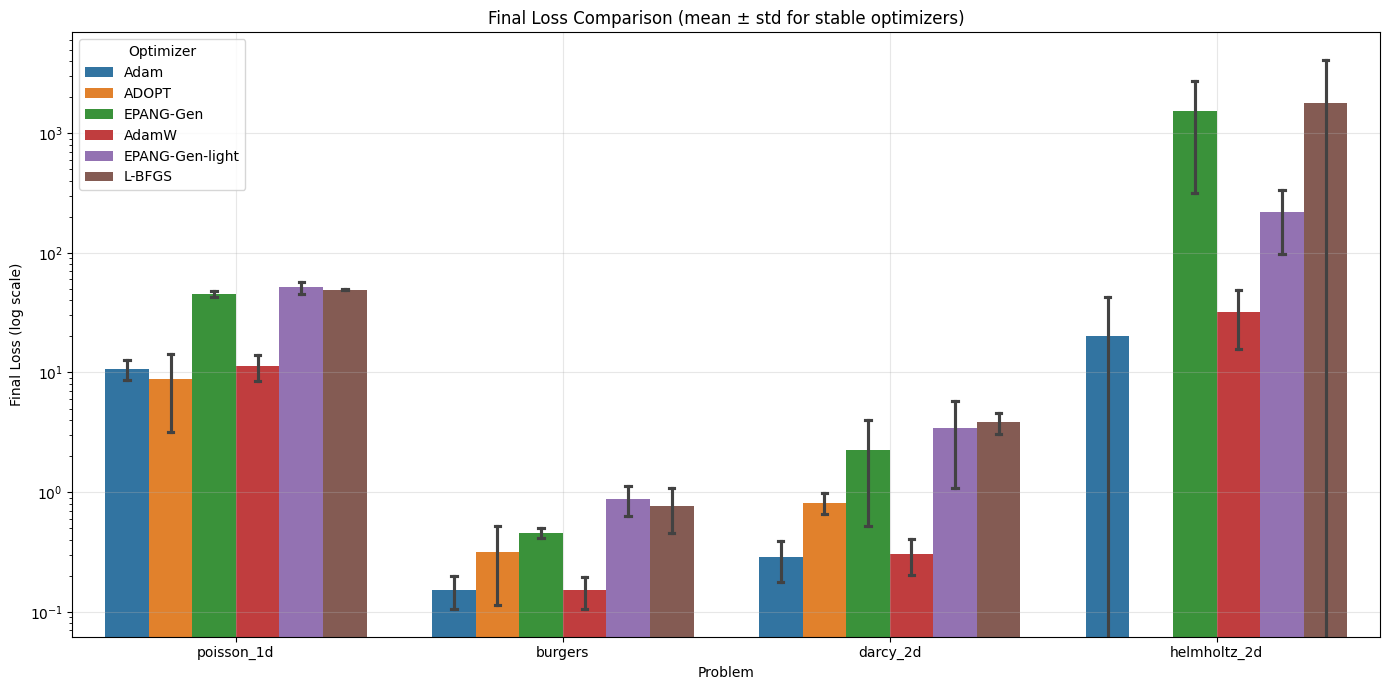

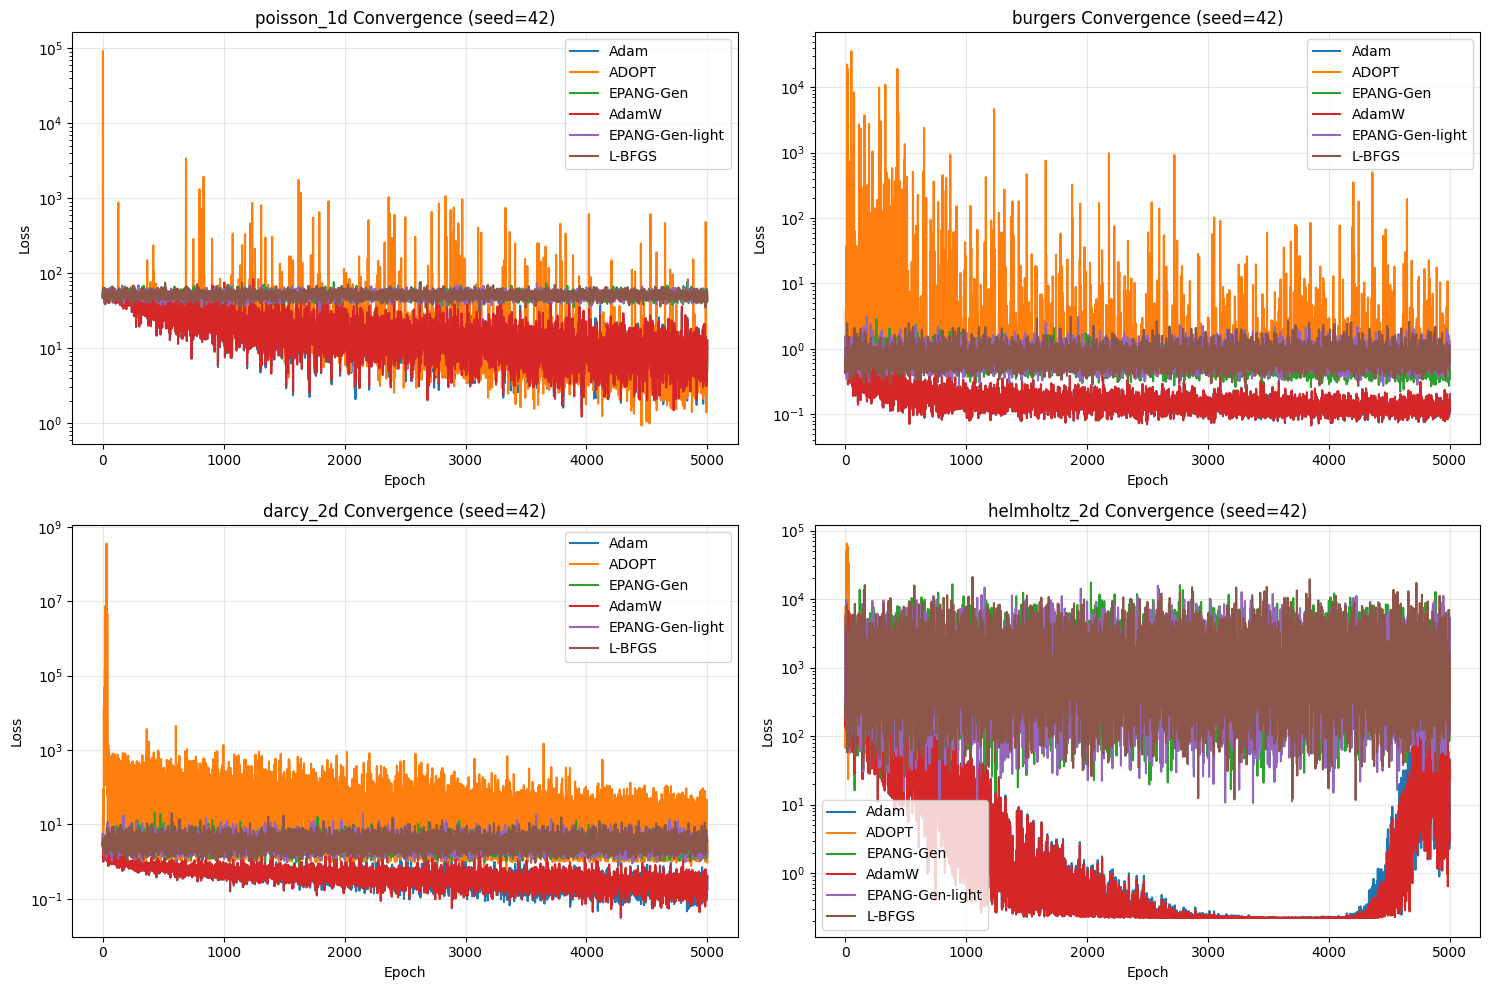

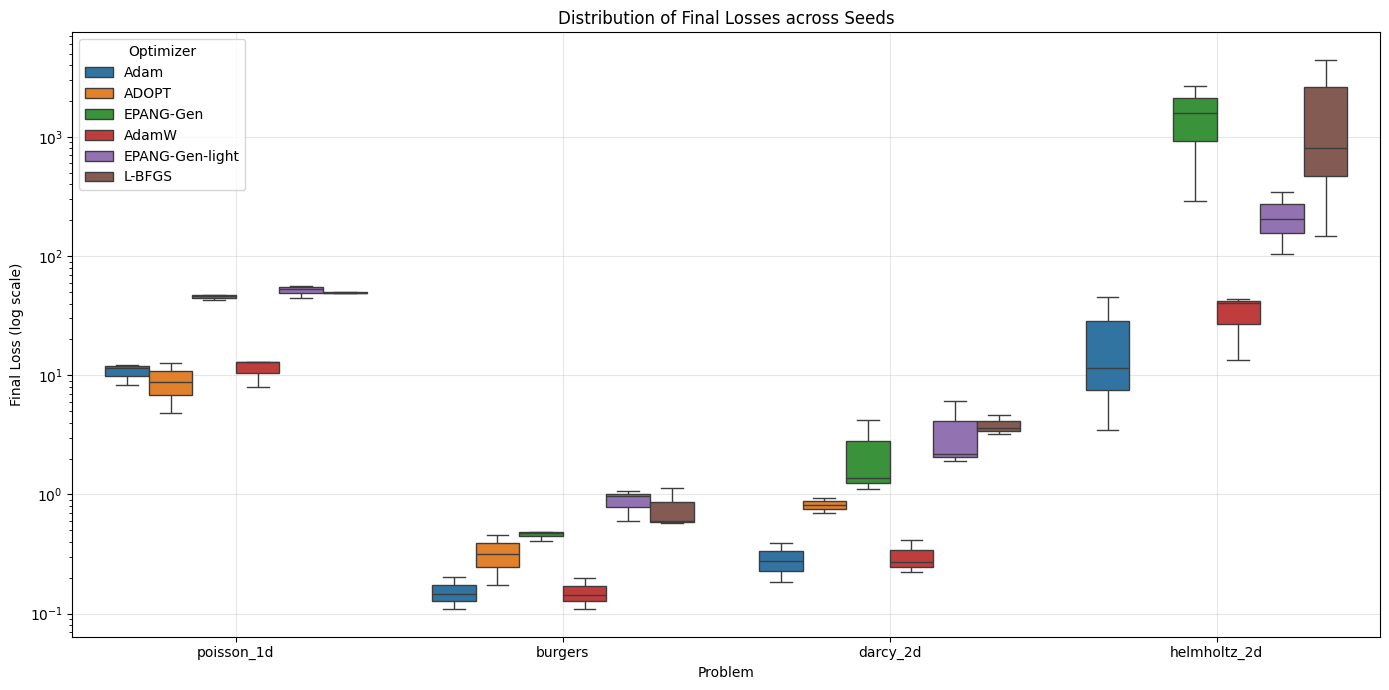

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# =============================================================================
# 9. Enhanced Statistics with Median for ADOPT & Visualizations
# =============================================================================
summary = {}
for opt_name in optimizers_to_run:
    for prob_name in problems_to_run:
        key = f"{opt_name}_{prob_name}"
        losses = [r['final_loss'] for r in results
                  if r['optimizer']==opt_name and r['problem']==prob_name]

        if opt_name == 'ADOPT':
            # Use median and IQR for unstable ADOPT
            clean_losses = [l for l in losses if not np.isnan(l)]
            if clean_losses:
                median = np.nanmedian(clean_losses)
                q75, q25 = np.nanpercentile(clean_losses, [75, 25])
                iqr = q75 - q25
                summary[key] = {
                    'median': float(median),
                    'iqr': float(iqr),
                    'raw': clean_losses,
                    'nan_count': len(losses) - len(clean_losses)
                }
        else:
            # Use mean and std for stable optimizers
            clean_losses = [l for l in losses if not np.isnan(l)]
            if clean_losses:
                mean = np.mean(clean_losses)
                std = np.std(clean_losses)
                summary[key] = {'mean': float(mean), 'std': float(std), 'raw': clean_losses}

with open('summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n=== EXPERIMENT COMPLETE ===")
print("Summary:", summary)


# Prepare data for plotting
plot_data = []
for r in results:
    if not np.isnan(r['final_loss']):
        plot_data.append({
            'Optimizer': r['optimizer'],
            'Problem': r['problem'],
            'Final Loss': r['final_loss'],
            'Seed': r['seed']
        })
df = pd.DataFrame(plot_data)

# Bar plot with error bars
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x='Problem', y='Final Loss', hue='Optimizer', errorbar='sd', capsize=0.1)
plt.yscale('log')
plt.title('Final Loss Comparison (mean ± std for stable optimizers)')
plt.ylabel('Final Loss (log scale)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_loss_comparison.png', dpi=150)
plt.show()

# Convergence curves
plt.figure(figsize=(15, 10))
for i, prob_name in enumerate(problems_to_run):
    plt.subplot(2, 2, i+1)
    for opt_name in optimizers_to_run:
        for r in results:
            if r['problem'] == prob_name and r['optimizer'] == opt_name and r['seed'] == 42:
                plt.plot(r['loss_history'], label=opt_name, linewidth=1.5)
                break
    plt.title(f'{prob_name} Convergence (seed=42)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_curves.png', dpi=150)
plt.show()

# Boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Problem', y='Final Loss', hue='Optimizer')
plt.yscale('log')
plt.title('Distribution of Final Losses across Seeds')
plt.ylabel('Final Loss (log scale)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=150)
plt.show()

# Download files
from google.colab import files
files.download('final_loss_comparison.png')
files.download('convergence_curves.png')
files.download('boxplot_comparison.png')
files.download('summary.json')